In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
data = {
    "CGPA": [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.5, 7.7, 7.8, 8.0,
        8.1, 8.2, 8.3, 8.4, 8.5,
        8.6, 8.7, 8.8, 8.9, 9.0,
        9.1, 9.2, 9.3, 9.4, 9.5,
        6.3, 6.6, 6.9, 7.1, 7.3,
        7.6, 7.9, 8.05, 8.15, 8.25,
        8.35, 8.45, 8.55, 8.65, 8.75
    ],

    "AptitudeScore": [
        45, 48, 50, 52, 55,
        58, 60, 62, 64, 66,
        68, 70, 72, 74, 76,
        78, 80, 82, 84, 86,
        88, 90, 92, 94, 95,
        47, 51, 54, 56, 59,
        61, 65, 67, 69, 71,
        73, 75, 77, 79, 81
    ],

    "CommunicationScore": [
        48, 50, 52, 54, 55,
        58, 60, 61, 63, 65,
        67, 69, 71, 73, 75,
        77, 79, 81, 83, 85,
        87, 89, 91, 93, 95,
        49, 53, 55, 57, 60,
        62, 64, 66, 68, 70,
        72, 74, 76, 78, 80
    ],

    "Internships": [
        0, 0, 1, 1, 1,
        1, 1, 2, 2, 2,
        2, 2, 2, 2, 2,
        2, 2, 3, 3, 3,
        3, 3, 3, 3, 3,
        0, 1, 1, 1, 1,
        2, 2, 2, 2, 2,
        2, 3, 3, 3, 3
    ],

    "Projects": [
        1, 1, 1, 2, 2,
        2, 2, 2, 3, 3,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4,
        4, 4, 4, 4, 4,
        1, 1, 2, 2, 2,
        2, 3, 3, 3, 3,
        3, 3, 4, 4, 4
    ],

    "Department": [
        "CSE", "CSE", "ECE", "ECE", "IT",
        "IT", "CSE", "CSE", "ECE", "IT",
        "CSE", "ECE", "IT", "CSE", "ECE",
        "IT", "CSE", "ECE", "IT", "CSE",
        "ECE", "IT", "CSE", "ECE", "IT",
        "CSE", "ECE", "IT", "CSE", "ECE",
        "IT", "CSE", "ECE", "IT", "CSE",
        "ECE", "IT", "CSE", "ECE", "IT"
    ],

    "Gender": [
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male"
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
display(df)

print("Shape:", df.shape)

Dataset:


,CGPA,AptitudeScore,CommunicationScore,Internships,Projects,Department,Gender
0,6.20,45,48,0,1,CSE,Female
1,6.50,48,50,0,1,CSE,Male
2,6.80,50,52,1,1,ECE,Female
3,7.00,52,54,1,2,ECE,Male
4,7.20,55,55,1,2,IT,Female
5,7.40,58,58,1,2,IT,Male
6,7.50,60,60,1,2,CSE,Female
7,7.70,62,61,2,2,CSE,Male
8,7.80,64,63,2,3,ECE,Female
9,8.00,66,65,2,3,IT,Male


Shape: (40, 7)


In [3]:
# Create a placement score

df["PlacementScore"] = (
    df["CGPA"] * 10
    + df["AptitudeScore"] * 0.35
    + df["CommunicationScore"] * 0.25
    + df["Internships"] * 8
    + df["Projects"] * 4
)

# Binary target

df["PlacementStatus"] = np.where(
    df["PlacementScore"] >= 100,
    "Placed",
    "Not Placed"
)


# Create CGPA Tier

def create_cgpa_tier(cgpa):

    if cgpa < 7.0:
        return "Low"

    elif cgpa < 8.0:
        return "Medium"

    else:
        return "High"


df["CGPA_Tier"] = df["CGPA"].apply(
    create_cgpa_tier
)


print("Placement Status:")
print(df["PlacementStatus"].value_counts())

print("\nCGPA Tier:")
print(df["CGPA_Tier"].value_counts())

Placement Status:
PlacementStatus
Placed        37
Not Placed     3
Name: count, dtype: int64

CGPA Tier:
CGPA_Tier
High      24
Medium    10
Low        6
Name: count, dtype: int64


In [4]:
feature_cols = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects",
    "Department",
    "Gender"
]

X = df[feature_cols]

print("Input Features:")
display(X.head())

Input Features:


,CGPA,AptitudeScore,CommunicationScore,Internships,Projects,Department,Gender
0,6.2,45,48,0,1,CSE,Female
1,6.5,48,50,0,1,CSE,Male
2,6.8,50,52,1,1,ECE,Female
3,7.0,52,54,1,2,ECE,Male
4,7.2,55,55,1,2,IT,Female


In [5]:
numeric_features = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects"
]

categorical_features = [
    "Department",
    "Gender"
]

In [6]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("OHE + Scaling Pipeline Created")

OHE + Scaling Pipeline Created


In [7]:
def evaluate_classifier(
    model,
    X_train,
    y_train,
    X_val,
    y_val
):

    # Train the model
    model.fit(
        X_train,
        y_train
    )

    # Training predictions
    train_pred = model.predict(
        X_train
    )

    # Validation predictions
    val_pred = model.predict(
        X_val
    )

    # Accuracy
    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    print("\n======================================")
    print("MODEL EVALUATION")
    print("======================================")

    print(
        "Train Accuracy:",
        round(train_accuracy, 4)
    )

    print(
        "Validation Accuracy:",
        round(val_accuracy, 4)
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            val_pred,
            zero_division=0
        )
    )

    return {
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Predictions": val_pred
    }

In [8]:
y_binary = df["PlacementStatus"]

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(

    X,
    y_binary,

    test_size=0.25,

    random_state=42,

    stratify=y_binary
)

print("Training samples:",
      len(X_train_b))

print("Validation samples:",
      len(X_val_b))

Training samples: 30
Validation samples: 10


In [9]:
binary_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [10]:
print("========== BINARY LOGISTIC REGRESSION ==========")

binary_results = evaluate_classifier(

    binary_model,

    X_train_b,
    y_train_b,

    X_val_b,
    y_val_b
)

========== BINARY LOGISTIC REGRESSION ==========

MODEL EVALUATION
Train Accuracy: 1.0
Validation Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         1
      Placed       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Confusion Matrix:
[[1 0]
 [0 9]]


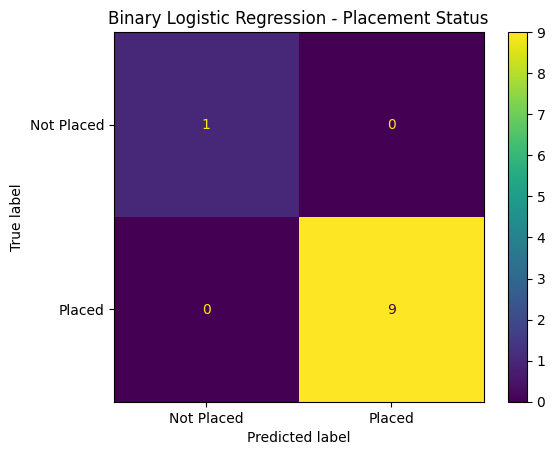

In [11]:
binary_predictions = binary_results["Predictions"]

cm = confusion_matrix(
    y_val_b,
    binary_predictions
)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_val_b,
    binary_predictions
)

plt.title(
    "Binary Logistic Regression - Placement Status"
)

plt.show()

In [12]:
feature_names = (
    binary_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    binary_model
    .named_steps["classifier"]
    .coef_[0]
)

coef_df = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": coefficients

})

coef_df = coef_df.sort_values(
    "Coefficient"
)

print("Coefficients:")
display(coef_df)

Coefficients:


,Feature,Coefficient
5,categorical__Department_CSE,-0.486244
9,categorical__Gender_Male,-0.086159
8,categorical__Gender_Female,0.086121
7,categorical__Department_IT,0.198970
6,categorical__Department_ECE,0.287235
2,numeric__CommunicationScore,0.416610
1,numeric__AptitudeScore,0.465871
4,numeric__Projects,0.585310
0,numeric__CGPA,0.650900
3,numeric__Internships,0.824221


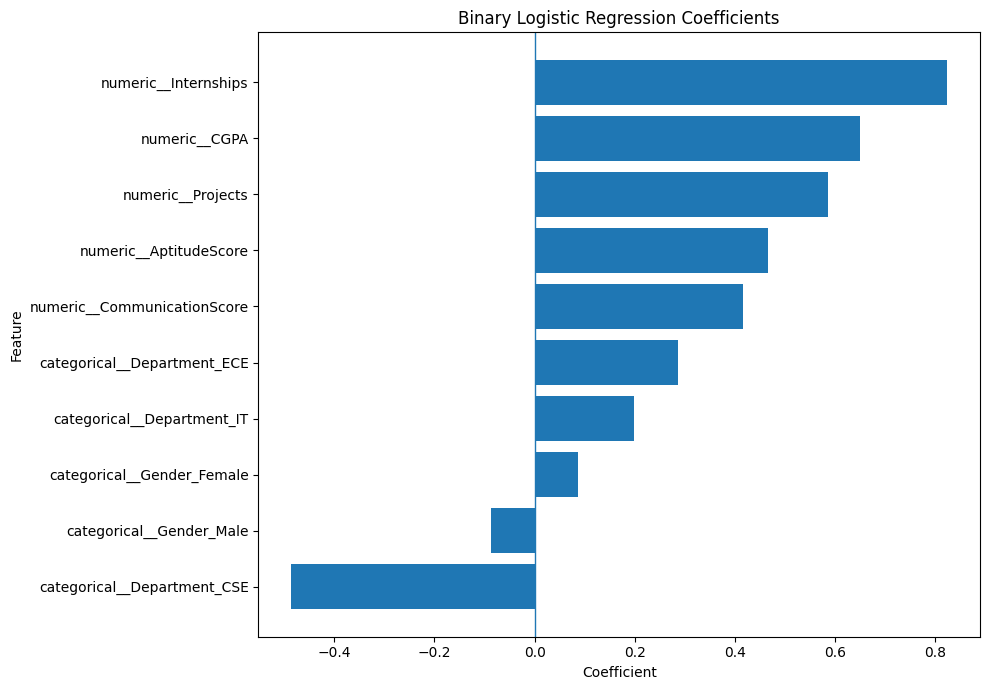

In [13]:
plt.figure(figsize=(10, 7))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Binary Logistic Regression Coefficients"
)

plt.tight_layout()

plt.show()

In [14]:
y_multi = df["CGPA_Tier"]

X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(

    X,
    y_multi,

    test_size=0.25,

    random_state=42,

    stratify=y_multi
)

print("Training samples:",
      len(X_train_m))

print("Validation samples:",
      len(X_val_m))

Training samples: 30
Validation samples: 10


In [15]:
multi_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                multi_class="multinomial",
                random_state=42
            )
        )
    ]
)

In [16]:
print("========== MULTINOMIAL LOGISTIC REGRESSION ==========")

multi_results = evaluate_classifier(

    multi_model,

    X_train_m,
    y_train_m,

    X_val_m,
    y_val_m
)

========== MULTINOMIAL LOGISTIC REGRESSION ==========

MODEL EVALUATION
Train Accuracy: 0.9333
Validation Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix:
[[6 0 0]
 [0 2 0]
 [0 0 2]]


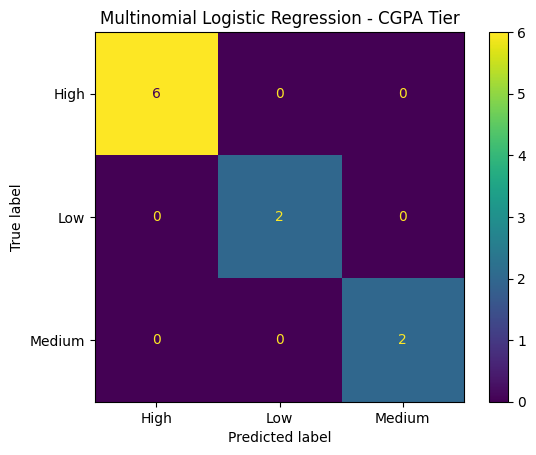

In [17]:
multi_predictions = multi_results["Predictions"]

cm_multi = confusion_matrix(
    y_val_m,
    multi_predictions
)

print("Confusion Matrix:")
print(cm_multi)

ConfusionMatrixDisplay.from_predictions(
    y_val_m,
    multi_predictions
)

plt.title(
    "Multinomial Logistic Regression - CGPA Tier"
)

plt.show()

In [18]:
multi_feature_names = (
    multi_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

multi_coefficients = (
    multi_model
    .named_steps["classifier"]
    .coef_
)

classes = (
    multi_model
    .named_steps["classifier"]
    .classes_
)

print("Classes:")
print(classes)

print("\nCoefficient Matrix Shape:")
print(multi_coefficients.shape)

Classes:
['High' 'Low' 'Medium']

Coefficient Matrix Shape:
(3, 10)


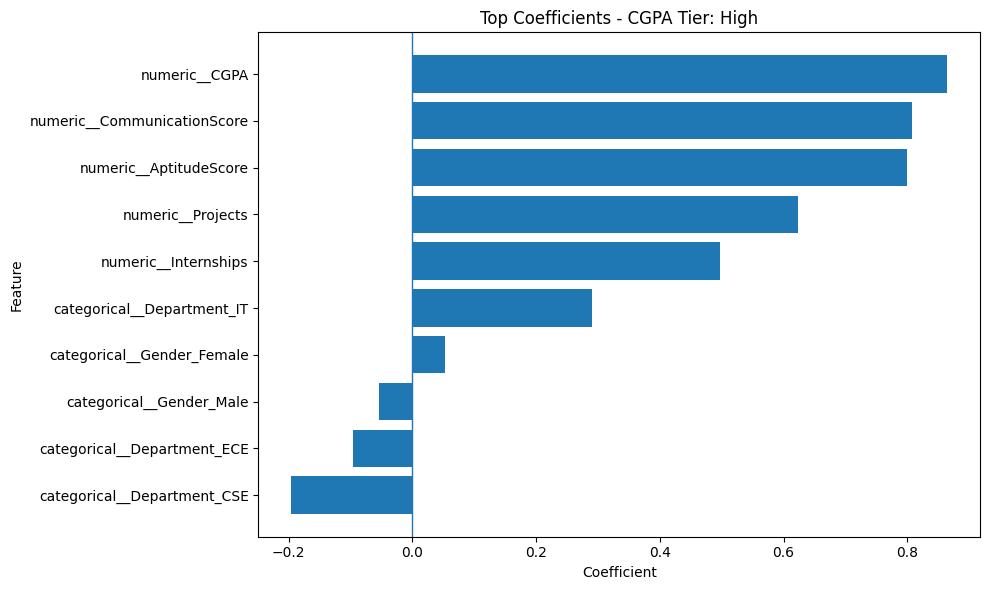

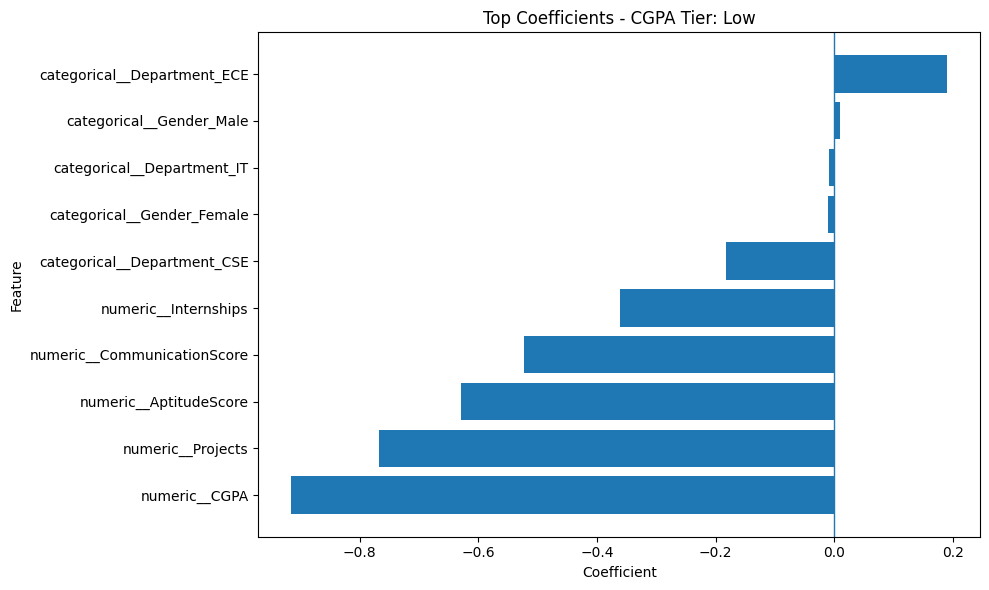

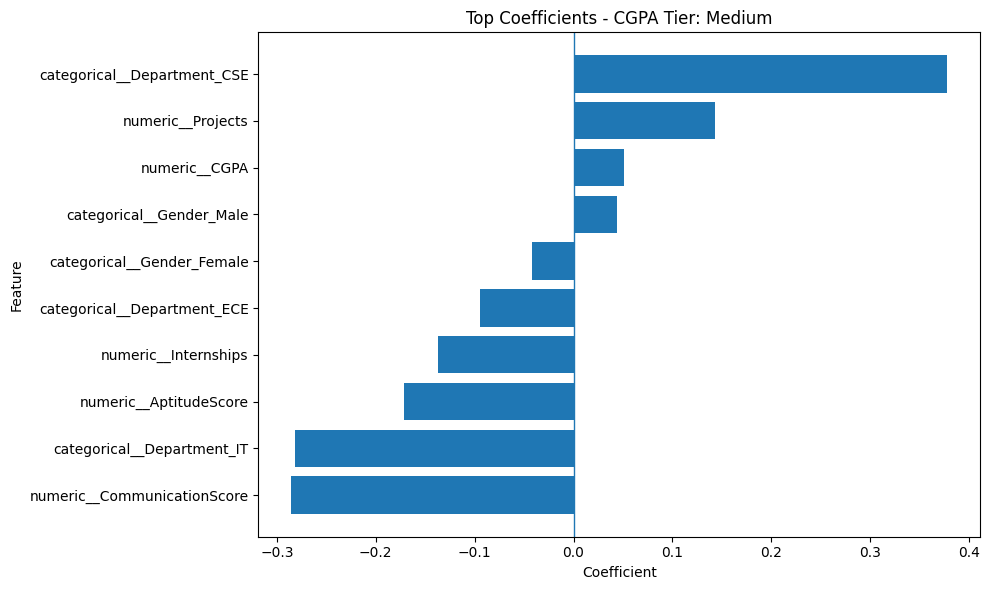

In [19]:
for i, class_name in enumerate(classes):

    coefficients = multi_coefficients[i]

    coef_df = pd.DataFrame({

        "Feature": multi_feature_names,

        "Coefficient": coefficients

    })

    coef_df["Absolute"] = (
        coef_df["Coefficient"].abs()
    )

    coef_df = coef_df.sort_values(
        "Absolute",
        ascending=False
    ).head(10)

    coef_df = coef_df.sort_values(
        "Coefficient"
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        coef_df["Feature"],
        coef_df["Coefficient"]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "Coefficient"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"Top Coefficients - CGPA Tier: {class_name}"
    )

    plt.tight_layout()

    plt.show()

In [20]:
# ============================================================
# MODEL 1 — BINARY PLACEMENT
# ============================================================

model_1 = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


# ============================================================
# MODEL 2 — MULTINOMIAL CGPA TIER
# ============================================================

model_2 = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                multi_class="multinomial"
            )
        )
    ]
)


# ============================================================
# MODEL 3 — BINARY MODEL WITH DIFFERENT C
# ============================================================

model_3 = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                C=0.5,
                max_iter=1000
            )
        )
    ]
)

In [21]:
print("\n\nMODEL 1: BINARY PLACEMENT STATUS")

result_1 = evaluate_classifier(

    model_1,

    X_train_b,
    y_train_b,

    X_val_b,
    y_val_b
)


print("\n\nMODEL 2: MULTINOMIAL CGPA TIER")

result_2 = evaluate_classifier(

    model_2,

    X_train_m,
    y_train_m,

    X_val_m,
    y_val_m
)


print("\n\nMODEL 3: BINARY PLACEMENT STATUS - C=0.5")

result_3 = evaluate_classifier(

    model_3,

    X_train_b,
    y_train_b,

    X_val_b,
    y_val_b
)



MODEL 1: BINARY PLACEMENT STATUS

MODEL EVALUATION
Train Accuracy: 1.0
Validation Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         1
      Placed       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



MODEL 2: MULTINOMIAL CGPA TIER

MODEL EVALUATION
Train Accuracy: 0.9333
Validation Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



MODEL 3: BINARY PLACEMENT STATUS - C=0.5

MOD

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [22]:
comparison = pd.DataFrame({

    "Model": [
        "Binary PlacementStatus",
        "Multinomial CGPA_Tier",
        "Binary PlacementStatus C=0.5"
    ],

    "Train Accuracy": [
        result_1["Train Accuracy"],
        result_2["Train Accuracy"],
        result_3["Train Accuracy"]
    ],

    "Validation Accuracy": [
        result_1["Validation Accuracy"],
        result_2["Validation Accuracy"],
        result_3["Validation Accuracy"]
    ]
})

print("========== FINAL MODEL COMPARISON ==========")

display(comparison)

========== FINAL MODEL COMPARISON ==========


,Model,Train Accuracy,Validation Accuracy
0,Binary PlacementStatus,1.000000,1.0
1,Multinomial CGPA_Tier,0.933333,1.0
2,Binary PlacementStatus C=0.5,1.000000,1.0
